# GroundingDINO-SAM2-YOLO Pipeline

Automatic annotation and refinement pipeline using Grounding DINO, SAM2, and YOLO for industrial computer vision applications.

## Research Workflow
- Video frame extraction
- Automatic annotation
- Prompt-based object localization
- SAM2 segmentation
- Dataset refinement
- YOLO dataset generation
- Experimental evaluation

## Author

1.   Karina Garcia
2.   Ivan Ramirez
3.   Jonathan Aguilar

Universidad Técnica de Machala


# Google Drive Configuration

This section mounts Google Drive and defines the directories used throughout the experimental workflow.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
workpath = '/content/drive/MyDrive/research'
datasetpath = workpath + "/dataset_eggs"

# Video Frame Extraction

Video frames are automatically extracted at different FPS rates to generate image datasets for downstream annotation and refinement.

In [ ]:
import os
path_image = datasetpath + "/dataset_eggs_3"
if not os.path.exists(path_image):
    os.makedirs(path_image)
    print(f"folder new: {path_image}")
else:
    print(f"folder already: {path_image}")

!ffmpeg -i "{workpath}/source_video/video_huevos_3.mp4" -start_number 1057 -vf "fps=1" "{workpath}/dataset/dataset_eggs_3/eggs_%04d.jpg"

In [ ]:
import shutil


dataset_path = "/content/drive/MyDrive/research/dataset/dataset_eggs_3"
zip_path = "/content/dataset_eggs_3.zip"


shutil.make_archive(zip_path.replace(".zip", ""), 'zip', dataset_path)

print(f"File: {zip_path}")


# Dataset Visualization

This section loads and visualizes the extracted images before the automatic annotation process.

**Lectura de imágenes en las carpetas**

# Grounding DINO + SAM2 Pipeline

This section configures the automatic annotation pipeline using Grounding DINO for object localization and SAM2 for segmentation.

# **GROUNDED DINO + SAM2**

In [ ]:
!rm -rf /content/Grounded-SAM-2

In [ ]:
!mkdir /content/Grounded-SAM2
%cd /content/Grounded-SAM2
!git clone https://github.com/facebookresearch/segment-anything-2.git

In [ ]:
%cd /content/Grounded-SAM2/segment-anything-2
!python setup.py install

# Model Checkpoint Download

Pretrained checkpoints are downloaded to initialize the segmentation models.

In [ ]:
%cd /content/Grounded-SAM2/segment-anything-2/checkpoints
!./download_ckpts.sh

# Grounding DINO Installation

Grounding DINO is installed to perform prompt-based object localization.

In [ ]:
%cd /content/
!git clone https://github.com/IDEA-Research/GroundingDINO.git

In [ ]:
%cd /content/GroundingDINO/
!pip install -r requirements.txt

In [ ]:
!pip install -e .

In [ ]:
import groundingdino
print("import GroundingDINO done.")

In [ ]:
!mkdir checkpoints
%cd checkpoints
!wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth

In [ ]:
!pip install hydra-core --force-reinstall

#Egg Extract

**Label Generate**

In [ ]:
import os
import cv2
import torch
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torchvision.ops import box_convert
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from GroundingDINO.groundingdino.util.inference import load_model, load_image, predict
from sklearn.ensemble import IsolationForest


TEXT_PROMPT = "egg"
DATASET_DIR = Path("/content/drive/MyDrive/research/dataset_eggs")
SAM2_CHECKPOINT = "/content/Grounded-SAM2/segment-anything-2/checkpoints/sam2.1_hiera_large.pt"
SAM2_MODEL_CONFIG = "configs/sam2.1/sam2.1_hiera_l.yaml"
GROUNDING_DINO_CONFIG = "/content/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py"
GROUNDING_DINO_CHECKPOINT = "/content/GroundingDINO/checkpoints/groundingdino_swint_ogc.pth"
BOX_THRESHOLD = 0.1
TEXT_THRESHOLD = 0.05
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


BASE_OUTPUT_DIR = Path("/content/dataset_huevos/")
IMAGES_DIR = BASE_OUTPUT_DIR / "images"
LABELS_DIR = BASE_OUTPUT_DIR / "labels"
STATS_DIR = BASE_OUTPUT_DIR / "stats"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
LABELS_DIR.mkdir(parents=True, exist_ok=True)
STATS_DIR.mkdir(parents=True, exist_ok=True)


sam2_model = build_sam2(SAM2_MODEL_CONFIG, SAM2_CHECKPOINT, device=DEVICE)
sam2_predictor = SAM2ImagePredictor(sam2_model)
grounding_model = load_model(GROUNDING_DINO_CONFIG, GROUNDING_DINO_CHECKPOINT)
grounding_model.to(DEVICE)


image_files = list(DATASET_DIR.glob("*.jpg"))
stats_data = []

for IMG_PATH in image_files:
    print(f"📌 Image proccess: {IMG_PATH.name}")
    start_time = time.time()


    img = cv2.imread(str(IMG_PATH))
    if img is None:
        print(f"⚠️ Warning: Don´t load {IMG_PATH}, skip...")
        continue

    h, w, _ = img.shape


    image_source, image = load_image(str(IMG_PATH))
    sam2_predictor.set_image(image_source)
    boxes, confidences, labels = predict(grounding_model, image, TEXT_PROMPT, BOX_THRESHOLD, TEXT_THRESHOLD)


    boxes = boxes.to(DEVICE) * torch.tensor([w, h, w, h], device=DEVICE)
    input_boxes = box_convert(boxes, in_fmt="cxcywh", out_fmt="xyxy").cpu().numpy()


    if len(input_boxes) > 1:
        clf = IsolationForest(contamination=0.1, random_state=42)
        anomalies = clf.fit_predict(input_boxes)
        valid_boxes = input_boxes[anomalies == 1]
    else:
        valid_boxes = input_boxes

    num_detected_eggs = len(input_boxes)
    num_segmented_eggs = len(valid_boxes)
    sizes = [((box[2] - box[0]), (box[3] - box[1])) for box in valid_boxes]


    labels_txt = []
    for box in valid_boxes:
        x1, y1, x2, y2 = map(int, box)

        center_x, center_y = (x1 + x2) // 2, (y1 + y2) // 2
        point_coords = torch.tensor([[center_x, center_y]], dtype=torch.float32, device=DEVICE)

        masks, _, _ = sam2_predictor.predict(
            point_coords=point_coords,
            point_labels=torch.tensor([1], dtype=torch.int, device=DEVICE),
            multimask_output=False
        )

        if masks is None or len(masks) == 0:
            continue


        mask_np = masks[0].astype(np.uint8)
        contours, _ = cv2.findContours(mask_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) == 0:
            continue


        largest_contour = max(contours, key=cv2.contourArea)
        yolo_contour = [(x[0][0] / w, x[0][1] / h) for x in largest_contour]
        label_line = "0 " + " ".join([f"{x:.6f} {y:.6f}" for x, y in yolo_contour])
        labels_txt.append(label_line)


    image_name = IMG_PATH.stem
    label_path = LABELS_DIR / f"{image_name}.txt"
    with open(label_path, "w") as f:
        for line in labels_txt:
            f.write(line + "\n")


    segmented_img_path = IMAGES_DIR / f"{image_name}.jpg"
    cv2.imwrite(str(segmented_img_path), img)


    end_time = time.time()
    processing_time = end_time - start_time
    avg_width, avg_height = np.mean(sizes, axis=0) if sizes else (0, 0)
    segmentation_diff = num_detected_eggs - num_segmented_eggs

    stats_data.append([
        IMG_PATH.name,
        num_detected_eggs,
        num_segmented_eggs,
        avg_width,
        avg_height,
        processing_time,
        segmentation_diff
    ])


df_stats = pd.DataFrame(stats_data, columns=[
    "image",
    "eggs detect",
    "eggs segment",
    "width average",
    "heigth average",
    "proccess time",
    "Detecgtion - Segment"
])


df_stats.to_csv(STATS_DIR / "statics_eggs.csv", index=False)

print("🎉 Process done")


In [ ]:
import shutil


zip_path = "/content/dataset_eggs.zip"


shutil.make_archive(zip_path.replace(".zip", ""), 'zip', "/content/dataset_eggs")


from google.colab import files
files.download(zip_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')


file_path = "/content/drive/MyDrive/research/dataset_eggs_yolo/stats/statics_eggs.csv"


df = pd.read_csv(file_path)


df.head()


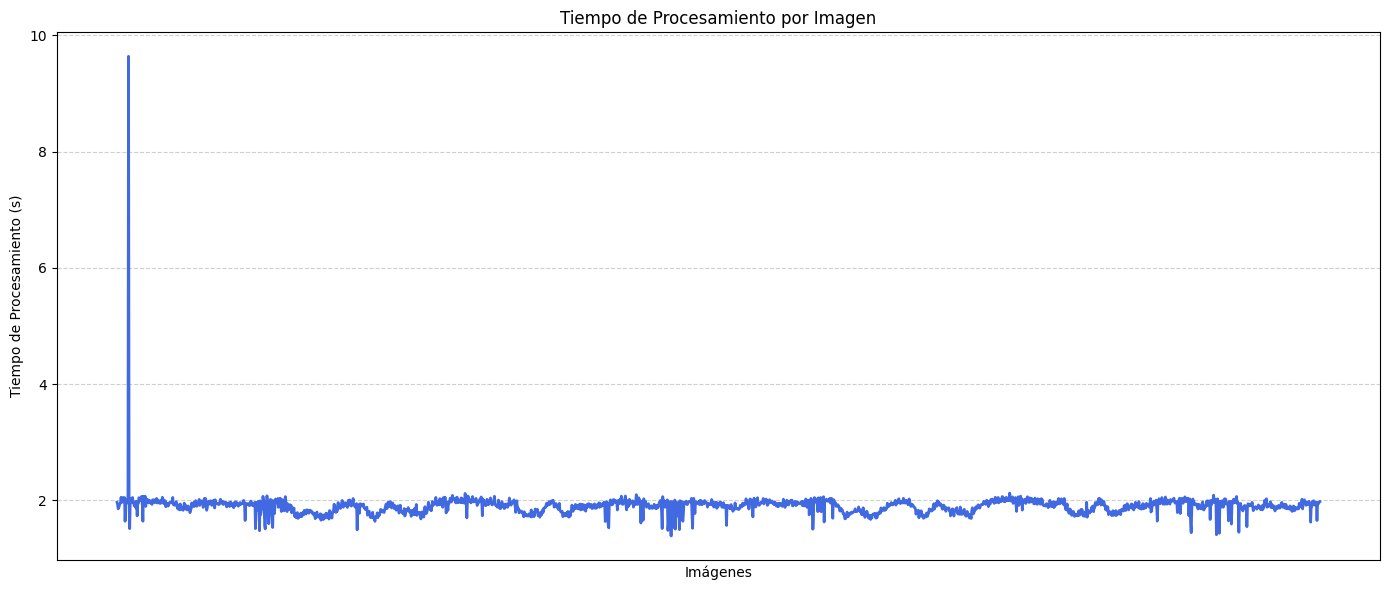

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(14, 6))
plt.plot(df["time_process"], linestyle="-", color="royalblue", linewidth=2)


plt.xticks([], [])

plt.xlabel("images")
plt.ylabel("time proccess (s)")
plt.title("time process for image")


plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


TypeError: 'Axes' object is not subscriptable

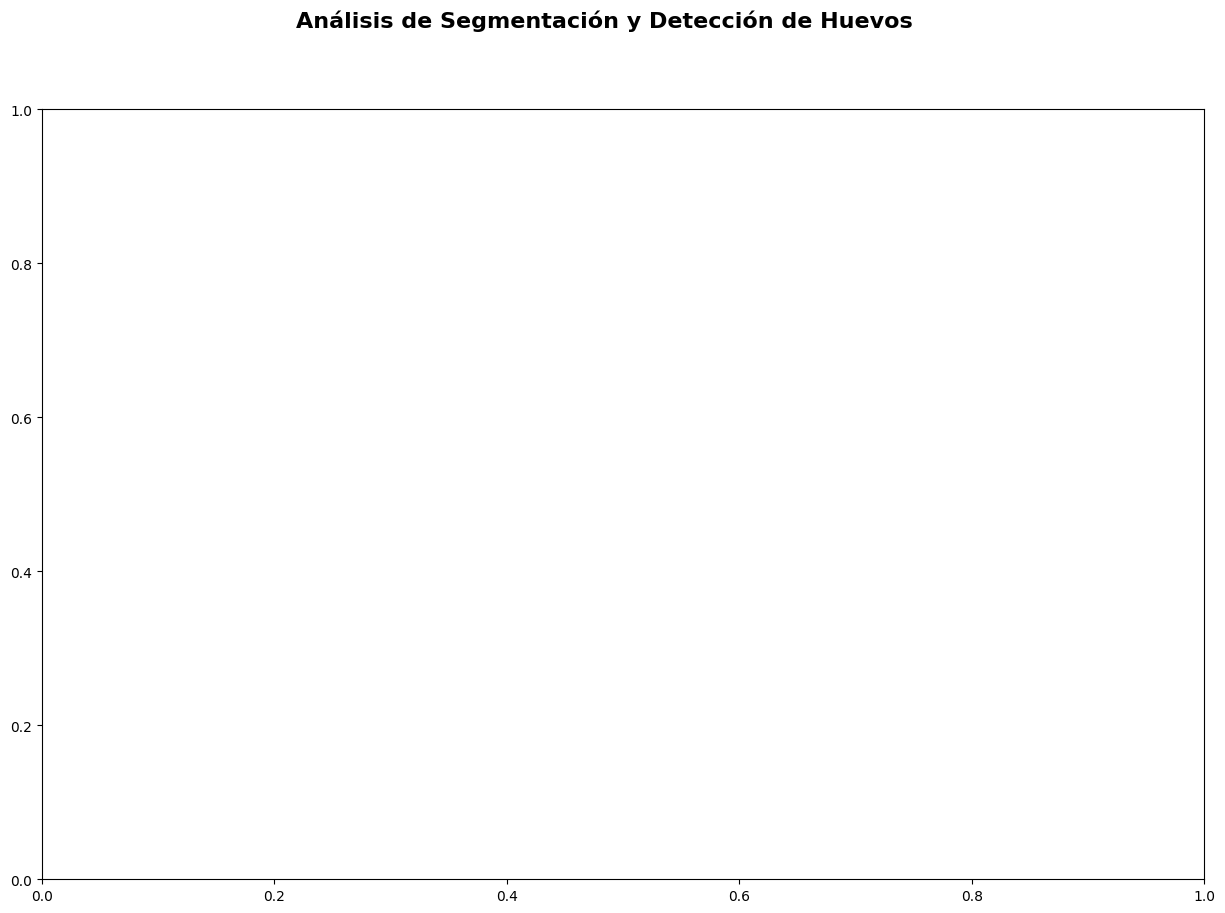

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear la figura y los subgráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Análisis de Segmentación y Detección de Huevos", fontsize=16, fontweight='bold')

# 📌 1. Gráfico acumulativo de huevos segmentados
axes[0, 0].plot(df.index, df["Huevos Segmentados"].cumsum(), marker="o", color="blue", markersize=2)
axes[0, 0].set_title("Gráfico Acumulativo de Huevos Segmentados")
axes[0, 0].set_xlabel("Imágenes")
axes[0, 0].set_ylabel("Total Acumulado de Huevos Segmentados")
axes[0, 0].grid()

# 📌 2. Tamaño promedio de los huevos por imagen
axes[0, 1].plot(df.index, df["Ancho Promedio"], label="Ancho Promedio", color="green")
axes[0, 1].plot(df.index, df["Alto Promedio"], label="Alto Promedio", color="orange")
axes[0, 1].set_title("Tamaño Promedio de los Huevos por Imagen")
axes[0, 1].set_xlabel("Imágenes")
axes[0, 1].set_ylabel("Tamaño (pixeles)")
axes[0, 1].legend()
axes[0, 1].grid()

# 📌 3. Gráfico de barras de huevos detectados vs. segmentados
axes[1, 0].bar(df.index, df["Huevos Detectados"], alpha=0.6, label="Detectados", color="blue")
axes[1, 0].bar(df.index, df["Huevos Segmentados"], alpha=0.6, label="Segmentados", color="red")
axes[1, 0].set_title("Huevos Detectados vs. Segmentados")
axes[1, 0].set_xlabel("Imágenes")
axes[1, 0].set_ylabel("Cantidad de Huevos")
axes[1, 0].legend()
axes[1, 0].grid()

# 📌 4. Análisis de outliers en tiempos de procesamiento (Scatter Plot)
axes[1, 1].scatter(df.index, df["Tiempo de Procesamiento"], color="purple", alpha=0.6, s=10)
axes[1, 1].set_title("Análisis de Outliers en Tiempos de Procesamiento")
axes[1, 1].set_xlabel("Imágenes")
axes[1, 1].set_ylabel("Tiempo de Procesamiento (s)")
axes[1, 1].grid()

# Ajustar diseño y mostrar
plt.tight_layout()
plt.subplots_adjust(top=0.9)

# Mostrar la imagen
plt.show()


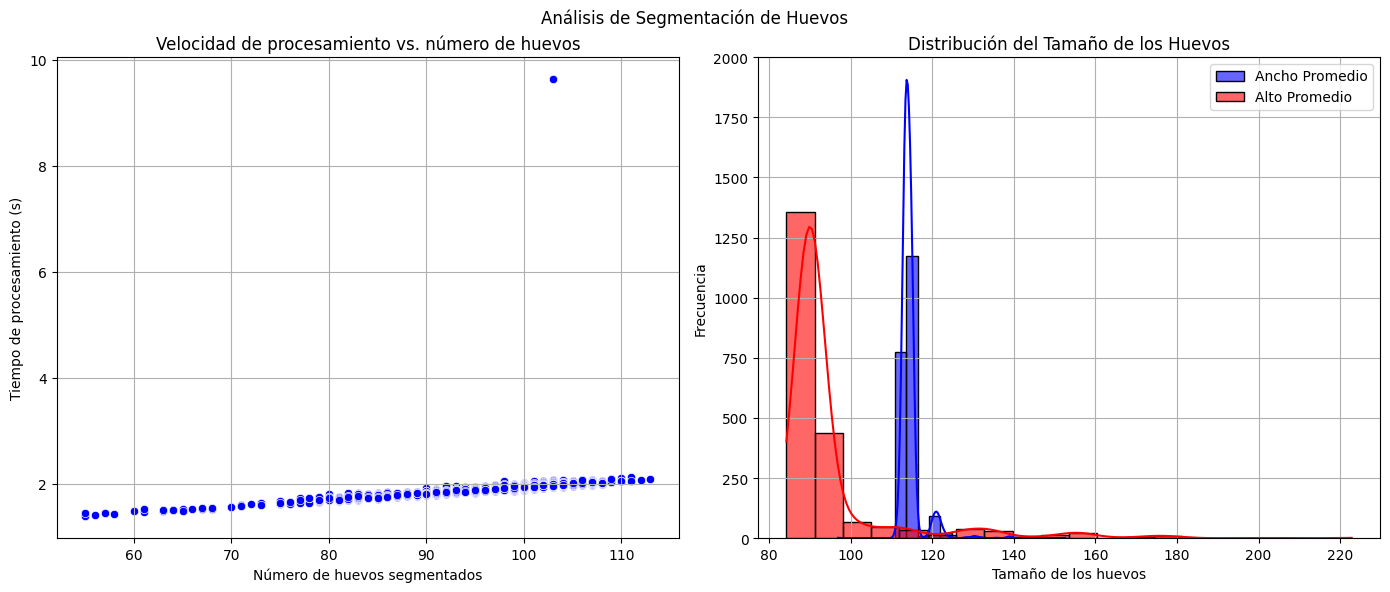

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 Crear la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Análisis de Segmentación de Huevos")

# 📌 1. Velocidad de procesamiento vs. número de huevos (Scatter plot)
sns.scatterplot(x=df["Huevos Segmentados"], y=df["Tiempo de Procesamiento"], ax=axes[0], color="blue")
axes[0].set_xlabel("Número de huevos segmentados")
axes[0].set_ylabel("Tiempo de procesamiento (s)")
axes[0].set_title("Velocidad de procesamiento vs. número de huevos")
axes[0].grid()

# 📌 2. Distribución del tamaño de los huevos (Histograma con KDE)
sns.histplot(df["Ancho Promedio"], bins=20, kde=True, label="Ancho Promedio", color="blue", alpha=0.6, ax=axes[1])
sns.histplot(df["Alto Promedio"], bins=20, kde=True, label="Alto Promedio", color="red", alpha=0.6, ax=axes[1])
axes[1].set_xlabel("Tamaño de los huevos")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución del Tamaño de los Huevos")
axes[1].legend()
axes[1].grid()

# 📌 Ajustar diseño y mostrar la imagen
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()


In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

# Verificar la instalación y mostrar la versión
YOLO().info()

In [ ]:
!pip install torchviz graphviz

In [ ]:
# load model YOLO11
model = YOLO("yolo11n.pt")

In [ ]:
from ultralytics import YOLO
import pandas as pd

# 📌 Obtener detalles de la arquitectura del modelo
model_info = {
    "Parámetro": [
        "Número de capas",
        "Parámetros entrenables",
        "Parámetros totales",
        "Flops (GFLOPs)",
        "Dimensión de entrada",
        "Número de clases",
        "Backbone",
        "Activación final"
    ],
    "Valor": [
        len(list(model.model.modules())),  # Contar capas en la arquitectura
        sum(p.numel() for p in model.model.parameters() if p.requires_grad),
        sum(p.numel() for p in model.model.parameters()),
        "No disponible",  # Flops no accesibles en YOLO11
        model.overrides.get("imgsz", "Desconocido"),  # Obtener imgsz
        len(model.names) if hasattr(model, "names") else "Desconocido",
        model.model[0].__class__.__name__ if hasattr(model.model, "__getitem__") else "Desconocido",
        model.model[-1].__class__.__name__ if hasattr(model.model, "__getitem__") else "Desconocido",
    ]
}

# 📌 Convertir a DataFrame con formato fila
df_config = pd.DataFrame(model_info)

# 📌 Mostrar la tabla en formato de texto plano
print(df_config.to_string(index=False))

# 📌 Guardar la tabla en un archivo de texto para copiar y pegar
file_path = "/content/YOLO11_configuracion.txt"
df_config.to_csv(file_path, sep="\t", index=False)

print(f"\n📄 La tabla ha sido guardada en: {file_path}")


             Parámetro         Valor
       Número de capas           238
Parámetros entrenables             0
    Parámetros totales       2582347
        Flops (GFLOPs) No disponible
  Dimensión de entrada           640
      Número de clases             1
              Backbone   Desconocido
      Activación final   Desconocido

📄 La tabla ha sido guardada en: /content/YOLO11_configuracion.txt


In [ ]:
# Entrenar el modelo con tus datos
model.train(data="/content/drive/MyDrive/research/eggs-TFM-UNIR.v2-eggs_database_1.yolov8-obb/data.yaml", epochs=100, imgsz=640, device="cuda")

In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# 📌 Directorio donde YOLO guarda los registros de entrenamiento
log_dir = "runs/detect/train"  # Asegúrate de que este directorio coincida con el de tu entrenamiento

# 📌 Cargar los datos de entrenamiento de YOLO
results_csv = os.path.join(log_dir, "results.csv")

# 📌 Verificar si el archivo existe
if not os.path.exists(results_csv):
    print(f"⚠️ El archivo {results_csv} no existe. Asegúrate de haber completado el entrenamiento.")
else:
    df = pd.read_csv(results_csv)

In [ ]:
print(df.columns)

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


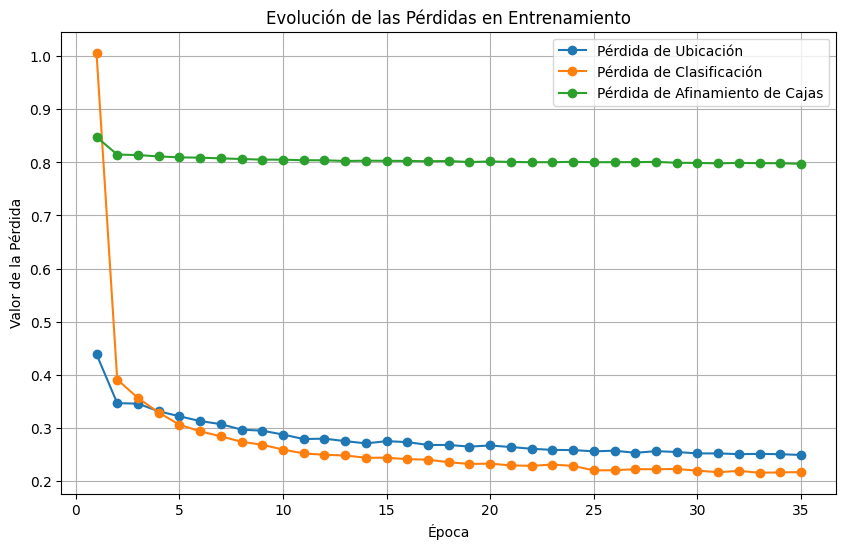

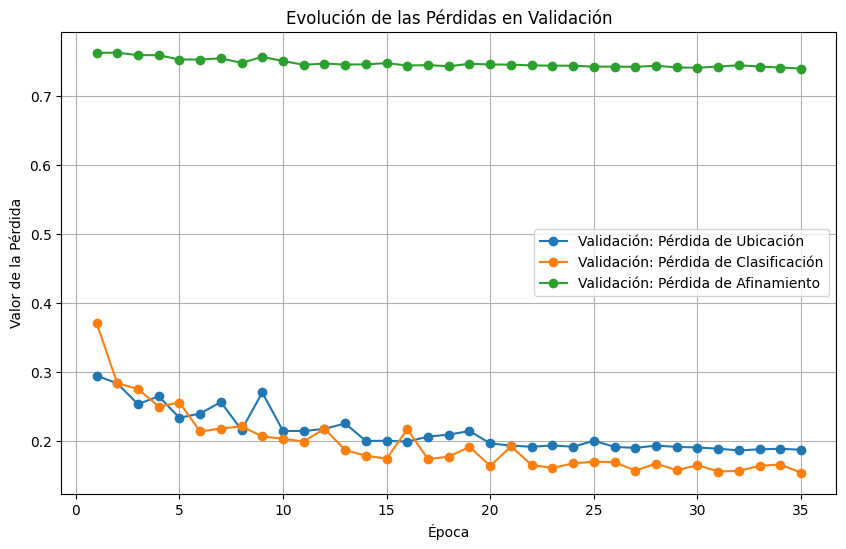

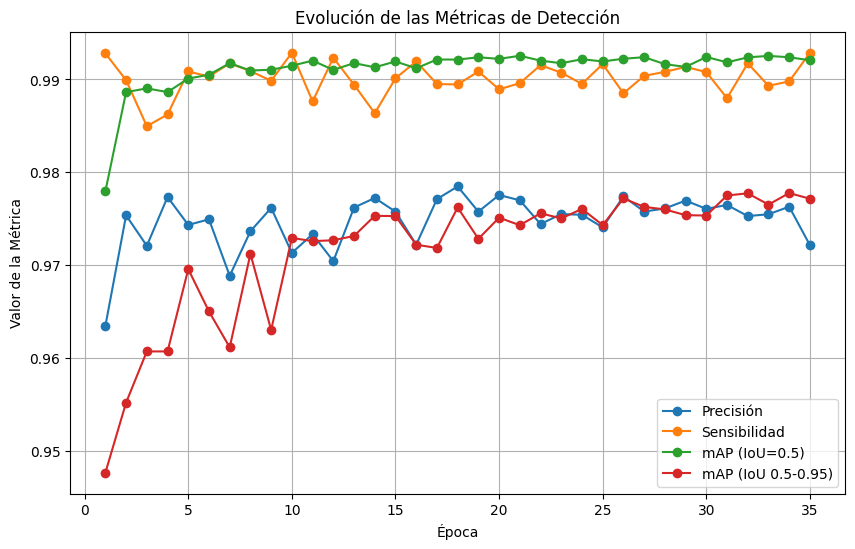

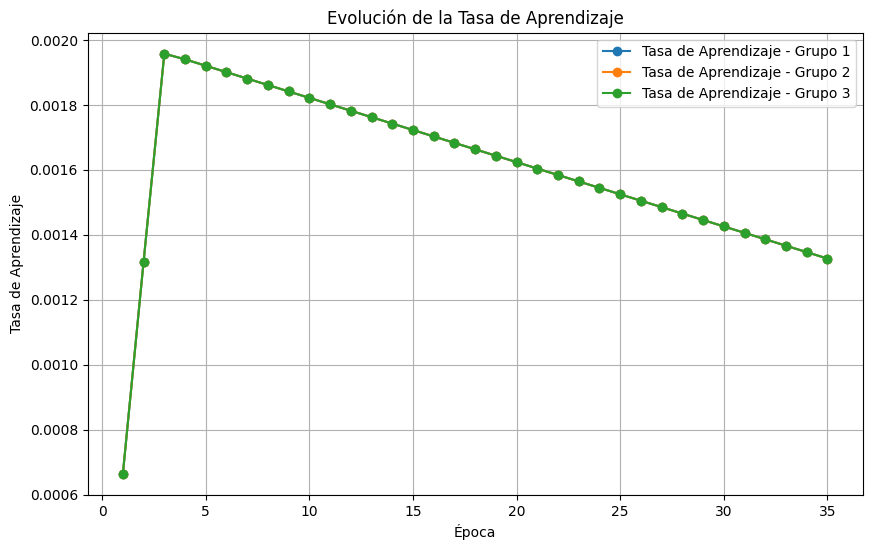

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar los datos desde un archivo CSV
# Asegúrate de que "log_training.csv" esté en la misma carpeta que tu script o ajusta la ruta.
df = pd.read_csv("/content/runs/detect/train/results.csv")

# 2. Renombrar las columnas para que sean más descriptivas
df = df.rename(columns={
    'train/box_loss': 'Pérdida de Ubicación',
    'train/cls_loss': 'Pérdida de Clasificación',
    'train/dfl_loss': 'Pérdida de Afinamiento de Cajas',
    'val/box_loss': 'Validación: Pérdida de Ubicación',
    'val/cls_loss': 'Validación: Pérdida de Clasificación',
    'val/dfl_loss': 'Validación: Pérdida de Afinamiento',
    'metrics/precision(B)': 'Precisión',
    'metrics/recall(B)': 'Sensibilidad',
    'metrics/mAP50(B)': 'mAP (IoU=0.5)',
    'metrics/mAP50-95(B)': 'mAP (IoU 0.5-0.95)',
    'lr/pg0': 'LR - Grupo 1',
    'lr/pg1': 'LR - Grupo 2',
    'lr/pg2': 'LR - Grupo 3'
})

# 3. Graficar la evolución de las pérdidas en el entrenamiento

plt.figure(figsize=(10, 6))
plt.plot(df['epoch'], df['Pérdida de Ubicación'], marker='o', label="Pérdida de Ubicación")
plt.plot(df['epoch'], df['Pérdida de Clasificación'], marker='o', label="Pérdida de Clasificación")
plt.plot(df['epoch'], df['Pérdida de Afinamiento de Cajas'], marker='o', label="Pérdida de Afinamiento de Cajas")
plt.xlabel("Época")
plt.ylabel("Valor de la Pérdida")
plt.title("Evolución de las Pérdidas en Entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

# 4. Graficar la evolución de las pérdidas en la validación

plt.figure(figsize=(10, 6))
plt.plot(df['epoch'], df['Validación: Pérdida de Ubicación'], marker='o', label="Validación: Pérdida de Ubicación")
plt.plot(df['epoch'], df['Validación: Pérdida de Clasificación'], marker='o', label="Validación: Pérdida de Clasificación")
plt.plot(df['epoch'], df['Validación: Pérdida de Afinamiento'], marker='o', label="Validación: Pérdida de Afinamiento")
plt.xlabel("Época")
plt.ylabel("Valor de la Pérdida")
plt.title("Evolución de las Pérdidas en Validación")
plt.legend()
plt.grid(True)
plt.show()

# 5. Graficar la evolución de las métricas de detección

plt.figure(figsize=(10, 6))
plt.plot(df['epoch'], df['Precisión'], marker='o', label="Precisión")
plt.plot(df['epoch'], df['Sensibilidad'], marker='o', label="Sensibilidad")
plt.plot(df['epoch'], df['mAP (IoU=0.5)'], marker='o', label="mAP (IoU=0.5)")
plt.plot(df['epoch'], df['mAP (IoU 0.5-0.95)'], marker='o', label="mAP (IoU 0.5-0.95)")
plt.xlabel("Época")
plt.ylabel("Valor de la Métrica")
plt.title("Evolución de las Métricas de Detección")
plt.legend()
plt.grid(True)
plt.show()

# 6. Graficar la evolución de la tasa de aprendizaje para cada grupo

plt.figure(figsize=(10, 6))
plt.plot(df['epoch'], df['LR - Grupo 1'], marker='o', label="Tasa de Aprendizaje - Grupo 1")
plt.plot(df['epoch'], df['LR - Grupo 2'], marker='o', label="Tasa de Aprendizaje - Grupo 2")
plt.plot(df['epoch'], df['LR - Grupo 3'], marker='o', label="Tasa de Aprendizaje - Grupo 3")
plt.xlabel("Época")
plt.ylabel("Tasa de Aprendizaje")
plt.title("Evolución de la Tasa de Aprendizaje")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Cargar el modelo entrenado
model = YOLO("/content/runs/detect/train/weights/best.pt")

In [ ]:
import os

# Ruta de la carpeta donde tienes las imágenes nuevas
image_folder = "/content/drive/MyDrive/research/dataset_prueba"

# Obtener la lista de imágenes
image_files = [os.path.join(image_folder, img) for img in os.listdir(image_folder) if img.endswith(('.jpg', '.png', '.jpeg'))]

# Aplicar el modelo a cada imagen
results = model(image_files, save=True, conf=0.5)




0: 384x640 106 0s, 1.1ms
1: 384x640 106 0s, 1.1ms
2: 384x640 106 0s, 1.1ms
3: 384x640 106 0s, 1.1ms
4: 384x640 107 0s, 1.1ms
5: 384x640 106 0s, 1.1ms
6: 384x640 106 0s, 1.1ms
7: 384x640 106 0s, 1.1ms
8: 384x640 108 0s, 1.1ms
9: 384x640 106 0s, 1.1ms
10: 384x640 106 0s, 1.1ms
Speed: 2.3ms preprocess, 1.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs/detect/predict4
